# 03 Seller Hook Analysis

本 notebook 对应仓库主线里的两条动作分支：一条是首单品类筛选，用来识别更像 `acquisition-quality screening` 的入口；另一条是卖家治理优先级，用来把供给侧问题收缩到可管理的 review queue。

依赖的数据口径也和 README 保持一致：首单来自首个 delivered 订单，`90d` 复购只在 `eligible_repurchase_90d=1` 的用户上解释；卖家治理使用 `shipping_limit_date` vs `carrier_date` 的 seller-side SLA proxy，以及 item `price` exposure proxy，而不是直接的因果归责或真实已实现收益。

## Section 0: Setup

In [ ]:
# ======================================================
# Section 0 (Cell 1/1): Load Data & Setup
# ======================================================

import os
import sys
from pathlib import Path
from datetime import datetime, timezone, timedelta

from sqlalchemy import create_engine
import yaml

try:
    from dotenv import load_dotenv
except Exception:  # pragma: no cover
    load_dotenv = None

# Timezone anchoring for reproducibility
TZ_UTC8 = timezone(timedelta(hours=8))
run_ts_utc8 = datetime.now(TZ_UTC8).strftime('%Y-%m-%d %H:%M:%S %z')
print(f'[UTC+8] Run timestamp: {run_ts_utc8}')

# Project root resolution (avoid hardcoding)
project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
os.chdir(project_root)

# Load config (config.yml / config.yaml)
config_candidates = [project_root / 'configs' / 'config.yaml', project_root / 'configs' / 'config.yml']
config_path = next((p for p in config_candidates if p.exists()), None)
if config_path is None:
    raise FileNotFoundError(f"No config file found. Searched: {[str(p) for p in config_candidates]}")
with open(config_path, 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

# Figures output
figures_dir = Path(config['paths']['figures_dir'])
figures_dir.mkdir(parents=True, exist_ok=True)

print(f"Figures will be saved to: {figures_dir}")

# Build engine (Optional for DATABASE_URL)
database_url = os.getenv('DATABASE_URL')
if database_url:
    engine = create_engine(database_url)
else:
    USER = os.getenv('DB_USER')
    PASSWORD = os.getenv('DB_PASS')
    HOST = os.getenv('DB_HOST', 'localhost')
    PORT = os.getenv('DB_PORT', '5432')
    DB = os.getenv('DB_NAME')

    missing = [k for k, v in {'DB_USER': USER, 'DB_PASS': PASSWORD, 'DB_NAME': DB}.items() if not v]
    if missing:
        raise RuntimeError('Missing required env vars (or set DATABASE_URL): ' + ', '.join(missing))

    engine = create_engine(f'postgresql+psycopg2://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB}')

[UTC+8] Run timestamp: 2026-03-09 00:58:11 +0800
Figures will be saved to: outputs\figures


## Section 1: Data Preparation (Atomic Items)

In [ ]:
# ======================================================
# Section 1 (Cell 1/1): Data Preparation (Atomic Items)
# ======================================================
# Attention: df_items 是 "item" 粒度的原子记录表, 用于首单入口质量筛选和卖家分析

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_items = pd.read_sql('SELECT * FROM analysis.analysis_items_atomic', engine)
print(f'✅ 原子化数据准备完成。行数: {len(df_items)} (比订单数多，因为包含了 Mixed Basket)')
df_items.head()

✅ 原子化数据准备完成。行数: 110189 (比订单数多，因为包含了 Mixed Basket)


,order_id,order_item_id,product_id,seller_id,price,category,review_score,has_review,delay_days,is_late
0,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,239.90,pet_shop,4.0,1,-2.330278,0
1,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,199.00,furniture_decor,5.0,1,-13.444954,0
2,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,199.90,garden_tools,5.0,1,-15.303808,0
3,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,21.90,housewares,4.0,1,-14.427373,0
4,00054e8431b9d7675808bcb819fb4a32,1,8d4f2bb7e93e6710a28f34fa83ee7d28,7040e82f899a04d1b434b795a43b4617,19.90,telephony,4.0,1,-16.080810,0


### Section 1 Summary

**Workflow**:
- 读取 `analysis.analysis_items_atomic` 作为后续首单入口质量筛选与卖家分析的最细粒度输入（Item-grain：`order_id + order_item_id`）。
- 把 `seller_id / category / price` 与 `review_score / delay_days / is_late` 对齐到同一行，保证后续 category / seller 聚合建立在统一口径上。

**Core Figure**:
- 原子表行数 `110,189`，高于订单数是预期行为，因为一个订单可以包含多个 item 和多个 seller。
- 这一步的核心价值是固化表粒度 (grain)，避免后续聚合时出现 fan-out 与分母漂移。

**Explanation**:
- item 粒度是为了给后续首单入口质量筛选与卖家分析提供共同的数据合同。
- 首单入口筛选使用品类层级而不是 SKU 层级，是为了避免样本过度稀疏，并让入口判断更稳定。
- 订单级的晚到与评分被贴到 item 粒度后，更适合做筛选与优先级排序，不适合直接做完美归责。
- 后续卖家治理里出现的 `price` 也是 item-price exposure proxy，不是支付口径 `GMV`。

---

## Section 2: First-Order Category Pool (Eligible Repurchasers)

In [ ]:
# ======================================================
# Section 2 (Cell 1/1): First-Order Category Pool
# ======================================================
# Logic: 
#   1. 这里先抽取"90d 发生过复购的用户,其首单里出现过哪些品类"
#   2. 尤其在 Olist 这种耐用品平台,用品类层级比要求同款 SKU 更稳定

# -----------------------------------
# 1) Load Data
# -----------------------------------
df_rfm = pd.read_sql("SELECT * FROM analysis.analysis_user_rfm", engine)
df_first_order_cats = pd.read_sql("SELECT * FROM analysis.analysis_user_first_order_categories", engine)

# -----------------------------------
# 2) Extract 90d Window Repurchasers
# -----------------------------------
# 右删失防御:仅在 eligible 用户上计算
df_rfm_elig = df_rfm[df_rfm["eligible_repurchase_90d"] == 1].copy()
repurchase_user_ids = df_rfm_elig[df_rfm_elig["repurchase_within_90d"] == 1]["user_id"]
print(f"Eligible users(90d window): {len(df_rfm_elig)}/{len(df_rfm)}")
print(f"90d窗口复购用户总数: {len(repurchase_user_ids)}")

# -----------------------------------
# 3) Extract First-order Category Pool
# -----------------------------------
# Grain: user-category (natural deduplication)
eligible_user_ids = df_rfm_elig["user_id"]
items_pool = df_first_order_cats[df_first_order_cats["user_id"].isin(eligible_user_ids)]
hook_items_pool = items_pool[items_pool["user_id"].isin(repurchase_user_ids)]

# -----------------------------------
# 4) Statistics of First-order Category
# -----------------------------------
# acquisition_users / retained_users 都是 distinct users (by construction)
item_counts = items_pool["category"].value_counts()
hook_counts = hook_items_pool["category"].value_counts()

print('\n [复购用户首单品类分布]')
print(f"复购用户首单包含的(用户,品类)行数: {len(hook_items_pool)}")
display(
    hook_counts
    .head(10)
)

# -----------------------------------
# 6) Decision-making
# -----------------------------------
# Attention: 只有当 Top 品类样本量足够大(比如 > 30),我们才能继续做首单入口筛选
top_1_count = hook_counts.iloc[0] if not hook_counts.empty else 0
top_1_cat = hook_counts.index[0] if not hook_counts.empty else 'N/A'

if top_1_count < 30:
    print(f"\n 样本严重不足! Top 1 品类 ({top_1_cat}) 仅在 {top_1_count} 个复购用户的首单中出现")
    print("结论: 试图从品类维度寻找规律存在巨大的'随机性风险',建议放弃品类分析，转向供给侧(卖家)分析。")
else:
    print(f"\n 初步验证结论:头部样本尚可")

Eligible users(90d window): 75385/93350
90d窗口复购用户总数: 978

 [复购用户首单品类分布]
复购用户首单包含的(用户,品类)行数: 994


category
bed_bath_table              144
sports_leisure              100
furniture_decor              79
health_beauty                79
watches_gifts                52
housewares                   45
computers_accessories        44
telephony                    41
toys                         39
fashion_bags_accessories     36
Name: count, dtype: int64


 初步验证结论:头部样本尚可


### Section 2 Summary

**Workflow**:
- 从 `analysis.analysis_user_rfm` 中取 `eligible_repurchase_90d=1` 且 `repurchase_within_90d=1` (Eligible 且 90d 发生复购) 的用户。
- 直接读取 `analysis.analysis_user_first_order_categories`，即首个 delivered 订单对应的 `(user_id, category)` 集合。
- 先看“发生过 90d 复购的用户，其首单篮子里出现过哪些品类”，为下一步和全体 eligible 用户做对照做准备。

**Core Figure**:
- 得到复购用户首单品类的 Top10 出现次数，但这些次数仍然强烈受基准流量影响。
- 因此，这一步只能说明“哪些品类在复购用户首单里更常见”，不能直接说明“哪些品类更像钩子品类”。

**Explanation**:
- 同一用户首单可以对应多个品类，所以这里的 cohort 天然重叠。
- 代码里的 `top_1_count < 30` 是 fail-fast 稳定性阈值，不是统计学最优 cutoff。
- 真正的筛选要到下一步，把品类放回 eligible 用户基线中比较 `90d` 复购率。

**Insights**:
- 这一步的作用是先把“复购用户从哪里进入”的描述性分布抽出来，避免后面直接把高频出现误读成高质量入口。
- 只有与整体 eligible 基线对照后，才能把品类当作候选入口筛选。

---

## Section 3: Hook Category Screen (Scale vs 90d repurchase)

Eligible用户90d复购率(基准线): 1.30%
Top 10 首单入口筛选候选 (按90d复购率排序):


,repurchased_users_90d,acquisition_users,repurchase_rate_90d
category,,,
fashion_bags_accessories,36,1442,2.50%
bed_bath_table,144,7183,2.00%
sports_leisure,100,6070,1.65%
furniture_decor,79,5054,1.56%
pet_shop,18,1193,1.51%
perfumery,32,2482,1.29%
watches_gifts,52,4045,1.29%
health_beauty,79,6203,1.27%
baby,26,2137,1.22%


.png already saved: outputs\figures\fig_03_hook_category_matrix.png


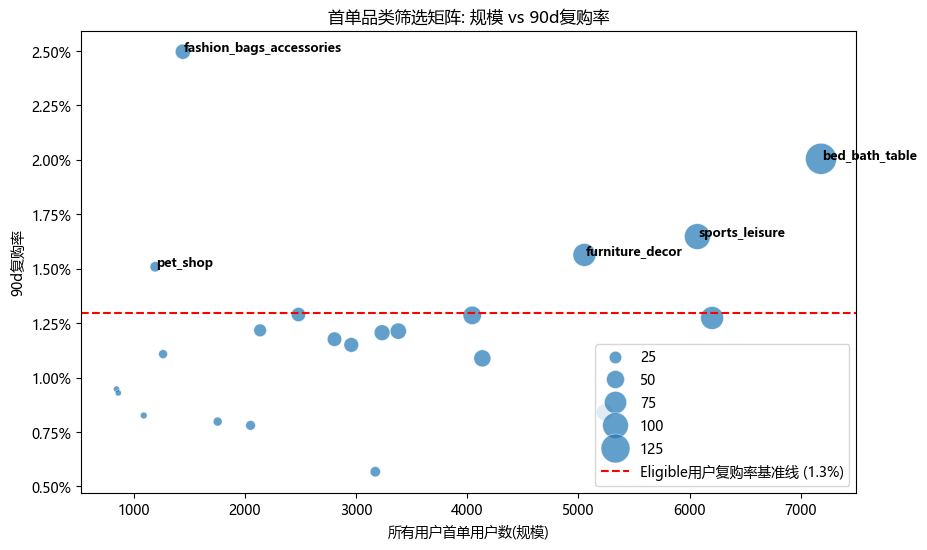

In [ ]:
# ======================================================
# Section 3 (Cell 1/1): Hook Category Screen
# ======================================================
# Logic: 进一步通过相对 90d 复购效率来筛选首单入口候选

import matplotlib as mpl
from matplotlib.ticker import PercentFormatter

# 保证中文正常显示
mpl.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans SC"]

# ----------------------------------------
# 1) Load Data
# ----------------------------------------
# items_pool:所有用户的首单品类信息
# item_counts:所有用户的首单品类出现次数
# hook_items_pool:复购用户的首单品类信息
# hook_counts:复购用户的首单品类出现次数
acquisition_counts = item_counts.rename("acquisition_users")
retention_counts = hook_counts.rename("retained_users")

# ----------------------------------------
# 2) Compute Conversion Rate
# ----------------------------------------
# concat(...,axis)表示把两张有相同 "index" 的表按列拼在一起
# 储存每个品类 (index) 对应的"所有用户首单出现次数","复购用户的首单出现次数"
hook_analysis = (
    pd.concat([acquisition_counts,retention_counts],axis=1)
    .fillna(0)
    .astype({"acquisition_users": "int64", "retained_users": "int64"})
)

# 计算每个品类对应的"复购率"(= "复购用户首单包含该品类的用户数" / "所有用户首单包含该品类的用户数")
hook_analysis["retention_rate"] = hook_analysis["retained_users"].astype("float64") / hook_analysis["acquisition_users"]

# ----------------------------------------
# 3) Filter Small Samples
# ----------------------------------------
# Logic:只看总获客数 > 500 的品类,保证稳健性
valid_hooks = hook_analysis[hook_analysis["acquisition_users"] > 500].sort_values("retention_rate", ascending=False)

# ----------------------------------------
# 4) Compute User-Level Repurchase Rate Baseline (eligible only)
# ----------------------------------------
# Baseline = P(repurchase_within_90d=1 | eligible_repurchase_90d=1)
# Attention: 
#   1. 不能用 sum(retained_users) / sum(acquisition_users) 跨品类求和来当用户基准线
#   2. 因为那是 (user,category) 对的加权结果
baseline_user = df_rfm_elig["repurchase_within_90d"].mean()

print(f"Eligible用户90d复购率(基准线): {baseline_user:.2%}")
print("Top 10 首单入口筛选候选 (按90d复购率排序):")
display(
    valid_hooks[["retained_users","acquisition_users","retention_rate"]]
    .head(10)
    .rename(columns={"retained_users": "repurchased_users_90d", "retention_rate": "repurchase_rate_90d"})
    .style.format({"repurchase_rate_90d":"{:.2%}"})
)

# ----------------------------------------
# 5) Visualize:"Scale vs Efficiency" Matrix
# ----------------------------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=valid_hooks,
    x="acquisition_users",
    y="retention_rate", 
    size="retained_users",
    sizes=(20, 500), 
    alpha=0.7
)

# Baseline line
plt.axhline(baseline_user, color="red", linestyle="--", label=f'Eligible用户复购率基准线 ({baseline_user:.1%})')
plt.title('首单品类筛选矩阵: 规模 vs 90d复购率')
plt.xlabel('所有用户首单用户数(规模)')
plt.ylabel('90d复购率')
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
plt.legend()

# Label top 5 categories
for i in range(5):
    row = valid_hooks.iloc[i]
    plt.text(
        row["acquisition_users"]+10, 
        row["retention_rate"], 
        valid_hooks.index[i],
        weight="bold", 
        fontsize=9
    )

fig = plt.gcf()

out = figures_dir / 'fig_03_hook_category_matrix.png'
fig.savefig(out, dpi=200, bbox_inches='tight')
print(f'.png already saved: {out}')
plt.show()

### Section 3 Summary

**Workflow**:
- 对每个首单品类同时计算两件事：
  1) `acquisition_users`：首单包含该品类的用户数
  2) `repurchased_users_90d`：在 eligible 用户中，`90d` 内发生复购且首单包含该品类的用户数
- 再用 `90d` 复购率与用户级基准线 `1.30%` 比较，并过滤 `acquisition_users > 500` 的小样本噪声。
- 代码变量里保留 `retained_users` / `retention_rate` 的旧命名，但当前解释应统一为 `90d` 复购用户数 / `90d` 复购率。

**Core Figure**:
- Eligible 用户 `90d` 复购率基准线为 `1.30%`。
- 在样本量足够的前提下，`fashion_bags_accessories`、`bed_bath_table`、`sports_leisure` 等品类高于基线。
- 因此更合理的表述是“首单入口质量筛选候选”，而不是“品类 lift 已被证明”。

**Explanation**:
- 这张图是规模与效率的联合筛选，不是因果估计。
- 同一用户首单可能对应多个品类，因此品类 cohort 不是互斥实验桶。
- `acquisition_users > 500` 只是 notebook 内的稳定性阈值，不应被误读成通用业务规则。

**Insight**:
- 在低复购平台里，更适合把这类品类当作首单入口筛选和后续实验候选，而不是直接承诺复购 uplift。
- 如果后续要做经营动作，应结合渠道、价格带和履约体验继续验证，而不是只看单一品类名称。

**Artifacts**:
- 已保存图表: `outputs/figures/fig_03_hook_category_matrix.png`

---

## Section 4: Seller Governance Matrix (Exposure proxy vs SLA gap)


[供给侧分析数据]
总活跃卖家(订单数大于30): 611
需要优先复核的 Bad 队列卖家数: 58 (占比 9.5%)
Bad 队列贡献的违约单比例: 15.4% (集中度 proxy)
.png already saved: outputs\figures\fig_03_seller_governance_matrix.png


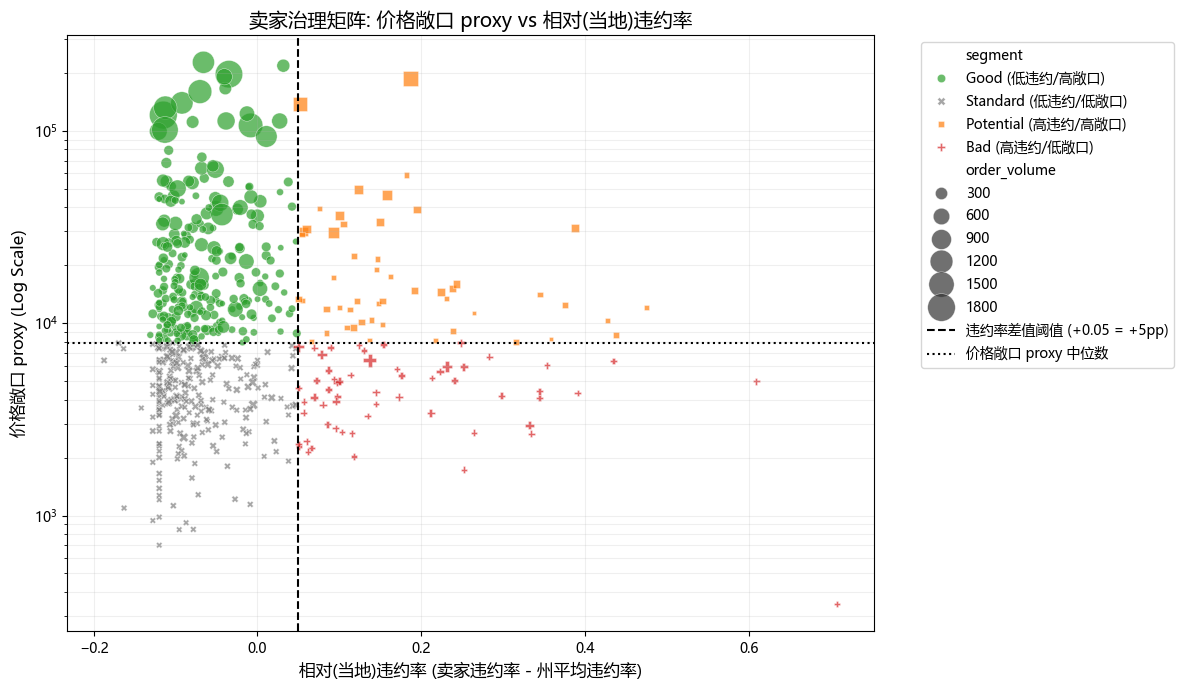

,seller_id,price,sla_breach_rate
segment,,,
Good (低违约/高敞口),254,"$7,432,127",5.4%
Potential (高违约/高敞口),51,"$1,260,125",29.4%
Standard (低违约/低敞口),248,"$1,119,539",4.3%
Bad (高违约/低敞口),58,"$263,811",29.6%


In [ ]:
# ======================================================
# Section 4 (Cell 1/1): Seller Governance Matrix
# ======================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ------------------------------------------
# 1) Data Preparation & Feature Engineering
# ------------------------------------------
# Motivation: 获取 shipping_limit_date (平台规定的商家最迟发货时间--SLA截止时间)
# Attention:
#   1. 同一个订单里面不同商品的卖家不同,同一订单的不同商品最迟发货时间也可能不同
#   2. 同一个订单所有商品的实际发货时间是一致的
# Olist.olist_order_items_dataset表记录了每个订单的SLA截止时间
# analysis.analysis_orders_obt表记录了每个订单的实际发货时间

# Load raw item data (including SLA end time)
df_raw_items = pd.read_sql(
"""
    SELECT 
        order_id, 
        order_item_id, 
        seller_id, 
        shipping_limit_date::TIMESTAMP AS shipping_limit_date, 
        price::numeric AS price 
    FROM Olist.olist_order_items_dataset
""", engine)

# Load OBT data (including actual delivery time)
df_obt_delivery = pd.read_sql(
"""
    SELECT 
        order_id, 
        carrier_ts AS carrier_date
    FROM analysis.analysis_orders_obt
""", engine)

# Join data
df_seller_audit = df_raw_items.merge(df_obt_delivery, on="order_id", how="inner")

# Convert time type
df_seller_audit["shipping_limit_date"] = pd.to_datetime(df_seller_audit["shipping_limit_date"])
df_seller_audit["carrier_date"] = pd.to_datetime(df_seller_audit["carrier_date"])

# Core indicator: seller-side SLA breach proxy (1=breach, 0=compliant)
# 逻辑: 卖家交接时间晚于最迟交接时间,提示卖家侧 SLA breach proxy,不是完整归责
df_seller_audit["is_sla_breach"] = (df_seller_audit["carrier_date"] > df_seller_audit["shipping_limit_date"]).astype(int)

# ------------------------------------------
# 2) Seller Information Aggregation (including geo info)
# ------------------------------------------
# Load seller geo info
df_sellers_geo = pd.read_sql("SELECT seller_id, seller_state FROM Olist.olist_sellers_dataset", engine)

# Aggregate calculation
seller_stats = df_seller_audit.groupby("seller_id").agg({
    
    # 计算卖家参与的不同订单数量以及参与的价格敞口 proxy
    'order_id': 'nunique',          # 订单量
    'price': 'sum',                 # item-price exposure proxy
    
    # 因为数值为0或1,直接取平均值可以得到违约率
    'is_sla_breach': 'mean'         # 违约率
}).rename(columns={'order_id': 'order_volume', 'is_sla_breach': 'sla_breach_rate'})

# Join geo info
seller_stats = seller_stats.merge(df_sellers_geo, on="seller_id", how="left")

# ------------------------------------------
# 3) Relative Performance Calculation (fairness calibration)
# ------------------------------------------
# Logic: 计算各州的"平均违约率"作为基准 (用来排除偏远地区揽收难的客观地理因素)
state_benchmark = seller_stats.groupby("seller_state")["sla_breach_rate"].mean().rename("state_avg_breach_rate")

# Join corresponding state baseline
seller_final = seller_stats.merge(state_benchmark, on='seller_state', how='left')

# 计算 Performance Gap (相对违约率 = 卖家违约率 - 当地平均违约率)
# Gap > 0: Slower than baseline (seller problem)
seller_final["performance_gap"] = seller_final["sla_breach_rate"] - seller_final["state_avg_breach_rate"]

# Filter tail (only consider sellers with order volume > 30)
main_sellers = seller_final[seller_final["order_volume"] > 30].copy()

# ------------------------------------------
# 4) Strategy Leveling (vectorized implementation)
# ------------------------------------------
# Logic: 计算卖家的 price 中位数,作为价格敞口 proxy 的划分基线
gmv_threshold = main_sellers["price"].median()

# 设定容忍度:绝对差值 5pp (performance_gap = seller - state_avg)
gap_threshold = 0.05

cond_lazy = main_sellers["performance_gap"] > gap_threshold
cond_rich = main_sellers["price"] > gmv_threshold

# Define label
conditions = [
    (cond_lazy & ~cond_rich),  # 发货慢且贡献小
    (cond_lazy & cond_rich),   # 发货慢且贡献大
    (~cond_lazy & cond_rich),  # 发货快且贡献大
    (~cond_lazy & ~cond_rich)  # 发货快且贡献小 (长尾)
]
choices = [
    'Bad (高违约/低敞口)', 
    'Potential (高违约/高敞口)', 
    'Good (低违约/高敞口)', 
    'Standard (低违约/低敞口)'
]

main_sellers["segment"] = np.select(conditions, choices, default="Standard")

# ------------------------------------------
# 5) Pareto Concentration Analysis
# ------------------------------------------
# Motivation: 计算高风险卖家队列的违约集中度

# Extract Bad sellers
bad_sellers = main_sellers[main_sellers["segment"].isin(['Bad (高违约/低敞口)'])]

# Bad 队列的违约单量 = Bad 队列订单数 × Bad 队列平均违约率
# Expected breached orders contributed by bad sellers (order-weighted)
bad_orders = (bad_sellers["order_volume"] * bad_sellers["sla_breach_rate"]).sum()

# 总期望违约单量 = 每个卖家的违约单量再加和
# 每个卖家的违约单量 = 订单数 × 总平均违约率
total_breach_orders = (main_sellers["order_volume"] * main_sellers["sla_breach_rate"]).sum()

# Bad 队列违约单占比 = Bad 队列违约单量 / 总违约单量
concentration_ratio = bad_orders / total_breach_orders if total_breach_orders > 0 else 0

print(f"\n[供给侧分析数据]")
print(f"总活跃卖家(订单数大于30): {len(main_sellers)}")
print(f"需要优先复核的 Bad 队列卖家数: {len(bad_sellers)} (占比 {len(bad_sellers)/len(main_sellers):.1%})")
print(f"Bad 队列贡献的违约单比例: {concentration_ratio:.1%} (集中度 proxy)")

# ------------------------------------------
# 6) Data Visualization (Governance Matrix)
# ------------------------------------------
# Motivation: 绘制散点图,对各类卖家分层可视化
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=main_sellers, 
    # x轴为相对(当地)违约率
    x="performance_gap", 
    # y轴为卖家的 item-price exposure proxy
    y="price", 
    hue="segment", 
    style="segment",
    palette={'Bad (高违约/低敞口)': '#d62728', 'Potential (高违约/高敞口)': '#ff7f0e', 
             'Good (低违约/高敞口)': '#2ca02c', 'Standard (低违约/低敞口)': 'grey'},
    size="order_volume", 
    sizes=(20, 400), 
    alpha=0.7
)

# Auxiliary line
plt.axvline(gap_threshold, color='black', linestyle='--', label=f'违约率差值阈值 (+{gap_threshold:.2f} = +5pp)')
plt.axhline(gmv_threshold, color='black', linestyle=':', label='价格敞口 proxy 中位数')

# Annotation
plt.title('卖家治理矩阵: 价格敞口 proxy vs 相对(当地)违约率', fontsize=14)
plt.xlabel('相对(当地)违约率 (卖家违约率 - 州平均违约率)', fontsize=12)
plt.ylabel('价格敞口 proxy (Log Scale)', fontsize=12)
plt.yscale('log')
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
fig = plt.gcf()

out = figures_dir / 'fig_03_seller_governance_matrix.png'
fig.savefig(out, dpi=200, bbox_inches='tight')
print(f'.png already saved: {out}')

plt.show()

display(main_sellers.groupby("segment").agg({
    'seller_id': 'count',
    'price': 'sum',
    'sla_breach_rate': 'mean'
}).sort_values('price', ascending=False).style.format({
    'price': '${:,.0f}', 
    'sla_breach_rate': '{:.1%}'
}))


### Section 4 Summary

**Workflow**:
- 用 `shipping_limit_date`（卖家承诺的最迟交接时间）与 `carrier_date`（实际交接给承运商时间）构造 `is_sla_breach`，把订单晚到与卖家交接责任尽量解耦。
- 聚合到 seller 粒度，得到 `order_volume`、`price`（item-price exposure proxy）、`sla_breach_rate`。
- 在 `seller_state` 上计算平均 breach rate，得到 `performance_gap = seller - state_avg`。
- 过滤 `order_volume > 30` 的长尾卖家后，用 `performance_gap > 5pp` 和 `price` 中位数分层构造治理矩阵。

**Core Figure**:
- 活跃卖家（`order_volume > 30`）共 `611` 个。
- `Bad` bucket 有 `58` 个卖家，占 `9.5%`；按当前 proxy 口径，其 breach-concentration 约 `15.4%`。
- 分群结果更适合被理解为治理 review queue，而不是自动处罚标签。

**Explanation**:
- `shipping_limit_date` vs `carrier_date` 只是 seller-side SLA proxy，不是完整归责链路。
- 这里的 `price` 是 item-price exposure proxy，不等同于支付口径 `GMV`。
- `order_volume > 30`、`performance_gap > 5pp`、按 `price` 中位数分层，都是 notebook 内的 heuristic thresholds。
- `Bad / Potential / Good / Standard` 是优先级标签，不应直接当作清退结论。

**Insight**:
- 这一步的价值是把“所有晚到卖家”收缩成更可操作的治理队列，再决定整改、扶持或约束动作。
- 其中 `Potential` 往往代表“规模不小、相对违约偏高”的卖家，更适合作为优先诊断对象，而不是默认直接处罚。

**Artifacts**:
- 已保存图表: `outputs/figures/fig_03_seller_governance_matrix.png`

---

## Section 5: Risk Exposure + Sensitivity


[商业价值核算]
风险敞口(高风险卖家价格敞口 proxy): 263,811.44
  - 这部分价格敞口由高风险卖家经手，平均(发货)违约率约为 29.6%
  - 若不治理，这部分订单更容易落入差评、退款或体验恶化风险，但这里不直接外推长期收益
.png already saved: outputs\figures\fig_03_roi_sensitivity_heatmap.png


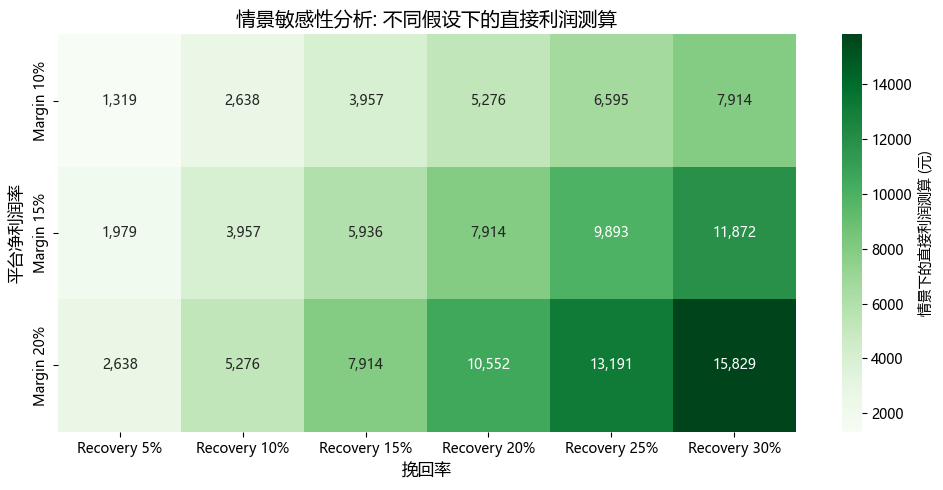


情景示例: 若按保守假设 (10% 挽回率, 15% 净利润率)
对应的直接利润敏感性约为: 3,957 元
(未纳入任何潜在长期效应，不应外推为总收益上下限)


In [ ]:
# ======================================================
# Section 5 (Cell 1/1): Risk Exposure + Sensitivity
# ======================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# ----------------------------------------
# 1) Compute Risk Exposure
# ----------------------------------------
# Definition: 由 Bad 队列卖家经手的价格敞口 proxy (Risk Exposure)
# Logic: 只要高风险卖家经手,体验/退款/差评风险上升,因此这部分价格敞口可视为优先治理的资金池 proxy

# Extract Bad sellers
bad_sellers_list = main_sellers[main_sellers["segment"] == 'Bad (高违约/低敞口)']["seller_id"]

# 计算 Bad 队列卖家涉及的总价格敞口 proxy
# 这里计算 total price,代表"高风险卖家能影响的生意规模 proxy"
gmv_at_risk = main_sellers[main_sellers["segment"] == 'Bad (高违约/低敞口)']["price"].sum()

# 计算 Bad 队列的违约率 (SLA Breach Rate)
bad_breach_rate = main_sellers[main_sellers["segment"] == 'Bad (高违约/低敞口)']["sla_breach_rate"].mean()

print(f"\n[商业价值核算]")
print(f"风险敞口(高风险卖家价格敞口 proxy): {gmv_at_risk:,.2f}")
print(f"  - 这部分价格敞口由高风险卖家经手，平均(发货)违约率约为 {bad_breach_rate:.1%}")
print(f"  - 若不治理，这部分订单更容易落入差评、退款或体验恶化风险，但这里不直接外推长期收益")

# --------------------------------------------------------
# 2) Sensitivity Analysis
# --------------------------------------------------------
# Logic: 不预测单一数值，而是计算在不同"治理成功率"下的收益矩阵
# Exploration: 如果将这部分订单转移给优质卖家(或通过治理让劣质卖家变好)，能挽回多少损失？
# Attention: 
#   1. 以下的探索性分析都建立在事先设定的数据基础上
#   2. 在实际的应用场景中仍需进一步的严谨性分析

# 挽回比例 (Recovery Rate): 对高风险 (Bad队列) 卖家进行治理后, 差评用户中预计转化为满意用户的比例
# 设定情景: 从 5% 到 30%
recovery_rates = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

# 净利润率 (Net Margin): 平台从售卖金额中获取的净利润率 (佣金+广告费)
# 设定情景: 10%, 15%, 20%
margin_rates = [0.10, 0.15, 0.20] 

# 构建"不同挽回比例、净利润率组合"下的直接利润敏感性矩阵
sensitivity_data = []
for margin in margin_rates:
    # 初始化
    row = []
    for rate in recovery_rates:
        # 直接利润测算 = 风险敞口 proxy * 挽回比例 * 净利润率
        saved_profit = gmv_at_risk * rate * margin
        row.append(saved_profit)
    sensitivity_data.append(row)

df_sensitivity = pd.DataFrame(
    sensitivity_data, 
    index=[f"Margin {m:.0%}" for m in margin_rates], 
    columns=[f"Recovery {r:.0%}" for r in recovery_rates]
)

# --------------------------------------
# 3) Visualization: Sensitivity Heatmap
# --------------------------------------
plt.figure(figsize=(10, 5))
sns.heatmap(df_sensitivity, annot=True, fmt=",.0f", cmap="Greens", cbar_kws={'label': '情景下的直接利润测算 (元)'})

plt.title('情景敏感性分析: 不同假设下的直接利润测算', fontsize=14)
plt.xlabel('挽回率', fontsize=12)
plt.ylabel('平台净利润率', fontsize=12)
plt.tight_layout()
fig = plt.gcf()

out = figures_dir / 'fig_03_roi_sensitivity_heatmap.png'
fig.savefig(out, dpi=200, bbox_inches='tight')
print(f'.png already saved: {out}')

plt.show()


print("\n情景示例: 若按保守假设 (10% 挽回率, 15% 净利润率)")
print(f"对应的直接利润敏感性约为: {gmv_at_risk * 0.1 * 0.15:,.0f} 元")
print("(未纳入任何潜在长期效应，不应外推为总收益上下限)")

### Section 5 Summary

**Workflow**:
- 用高风险卖家的 item-price exposure proxy 测算需要优先关注的风险敞口。
- 在不同 `recovery_rate` 与 `margin` 假设下做情景敏感性分析，而不是给出单点收益预测。

**Core Figure**:
- 当前 proxy 口径下的 exposure 为 `263,811.44`。
- `Bad` bucket 的平均 SLA breach rate 为 `29.6%`。
- 在保守情景（`10%` 挽回率、`15%` 净利润率）下，对应的只是直接收益测算示例，不是已经实现的财务回报。

**Explanation**:
- 这里的 `gmv_at_risk` 更准确地说是 price-weighted exposure proxy，不是真实损失。
- `recovery_rate` 与 `margin` 都是情景假设，热力图的作用是展示区间敏感性，而不是输出精确预测。
- 当前 notebook 不应继续外推到“留存提升 -> LTV 提升”的硬结论，因为这部分没有在本节被单独量化。

**Insight**:
- 这张表更适合用来说明“为什么值得先做治理优先级”，而不是承诺固定 ROI。
- 真正落地时，应把它与治理队列、履约改造方案和后续复盘指标一起使用。

**Artifacts**:
- 已保存图表: `outputs/figures/fig_03_roi_sensitivity_heatmap.png`

---